# Customer Segmentation using K-Means Clustering

## Internship Task 2

### Objective
To group customers of a retail store based on their purchase history using the K-Means Clustering algorithm.

### Dataset
Mall Customers Dataset

### Algorithm
K-Means Clustering

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display graphs inside notebook
%matplotlib inline

In [2]:
# Load Dataset

df = pd.read_csv("../data/Mall_Customers.csv")

# Display first five rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape of Dataset :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset : (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Data Types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [4]:
df.info()
df.describe()
df.isnull().sum()
print("Duplicate Rows :", df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
Duplicate Rows : 0


## Observation

- Dataset contains 200 customer records.
- Dataset contains 5 columns.
- No missing values are present.
- No duplicate records are present.
- Data is clean and ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

## Objective
Explore the customer dataset to understand the distribution of different features and identify patterns that will help in customer segmentation using K-Means Clustering.

# Customer Gender Distribution

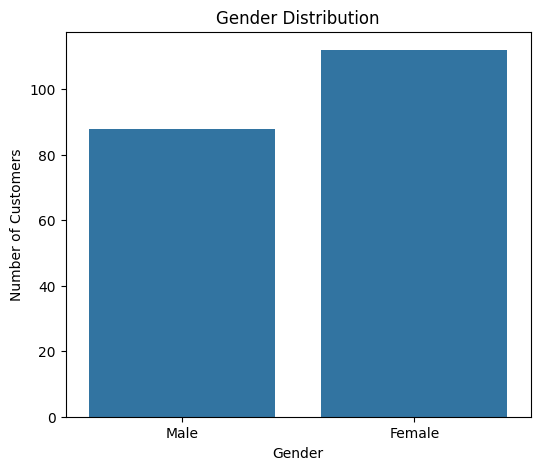

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The dataset contains both Male and Female customers.
- The gender distribution is almost balanced.
- Gender will not be used directly for K-Means clustering because it is a categorical feature.

# Age Distribution

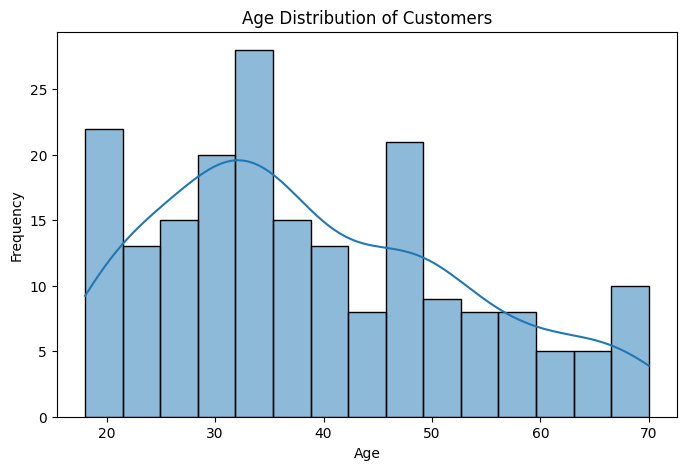

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most customers belong to the young and middle-aged groups.
- Very few customers are above 60 years.
- Age is an important feature for customer segmentation.

# Annual Income Distribution

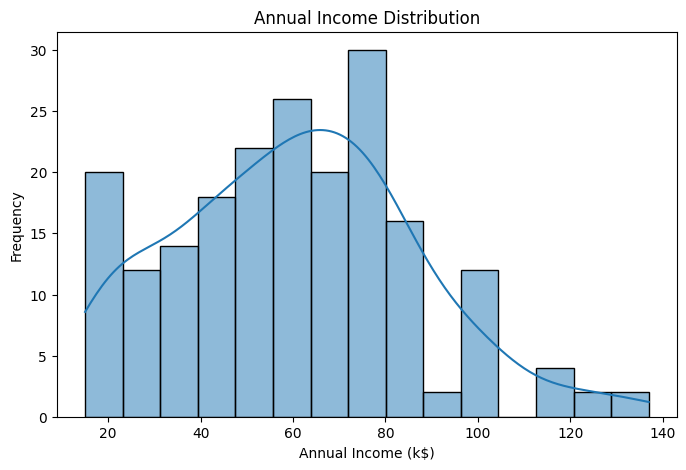

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

### Observation

- Annual income varies significantly among customers.
- The dataset contains customers with both low and high incomes.
- This feature is expected to play an important role in clustering.

# Spending Score Distribution

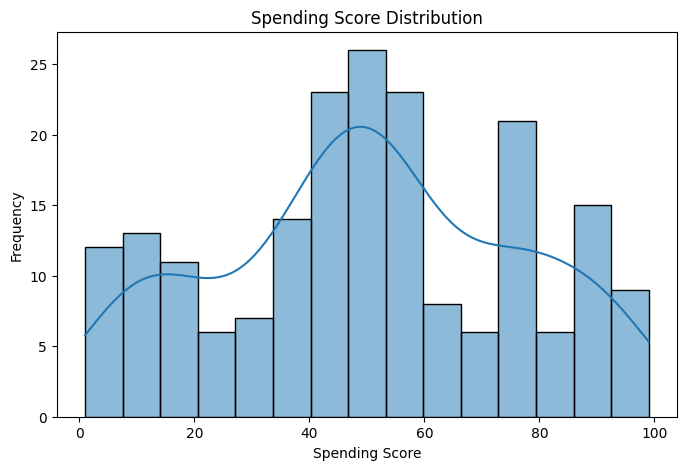

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

### Observation

- Customers exhibit a wide range of spending behaviors.
- Spending Score is one of the most important variables for customer segmentation.

# Boxplots (Outlier Detection)

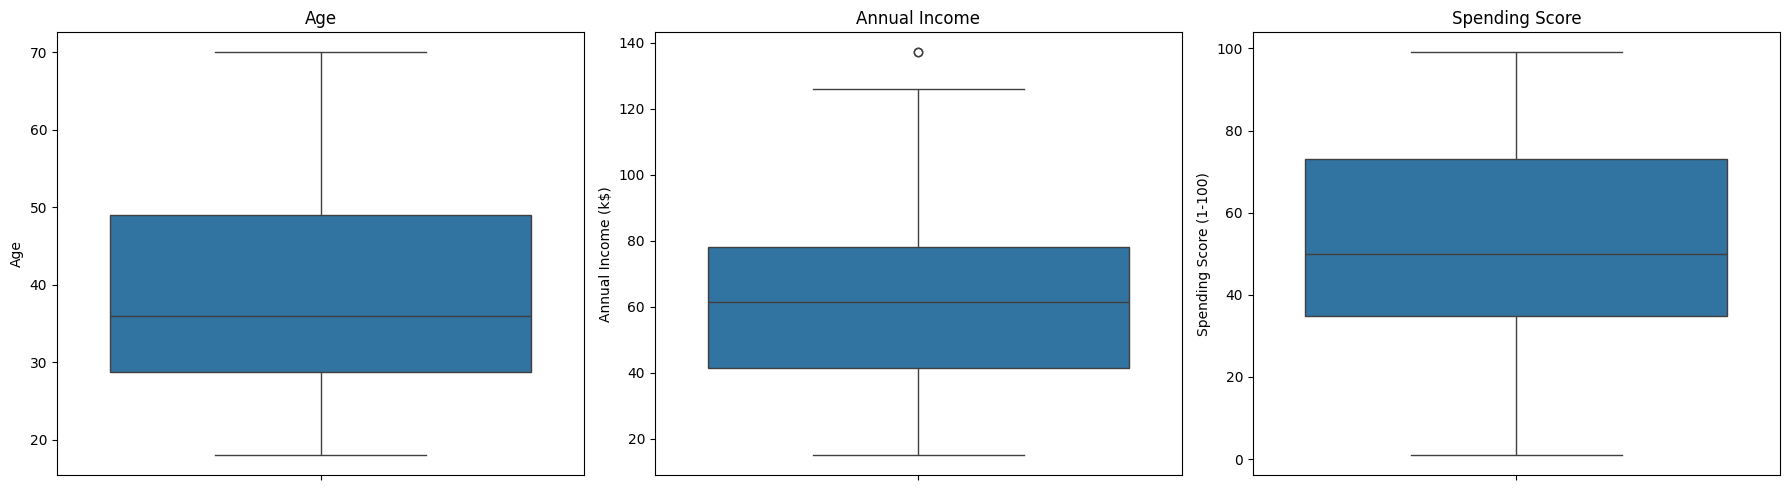

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(y=df['Age'], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(y=df['Annual Income (k$)'], ax=axes[1])
axes[1].set_title("Annual Income")

sns.boxplot(y=df['Spending Score (1-100)'], ax=axes[2])
axes[2].set_title("Spending Score")

plt.tight_layout()

plt.show()

### Observation

- Boxplots help identify potential outliers.
- Minor outliers may exist but are acceptable for K-Means.
- No extreme values requiring removal are observed.

# Correlation Matrix

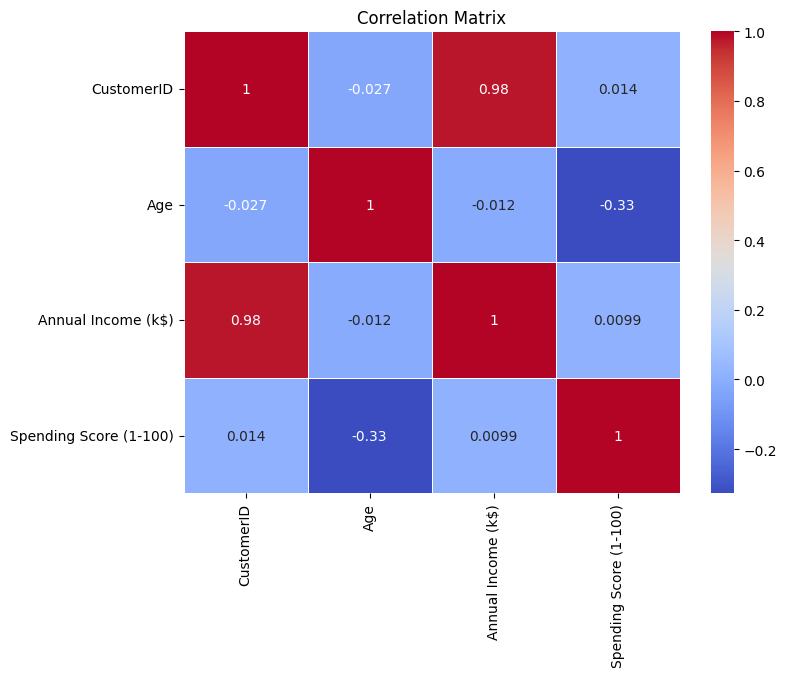

In [10]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Observation

- Correlation values are relatively low.
- No strong linear relationship exists between the numerical variables.
- K-Means does not require highly correlated features, making this acceptable.

# Pair Plot

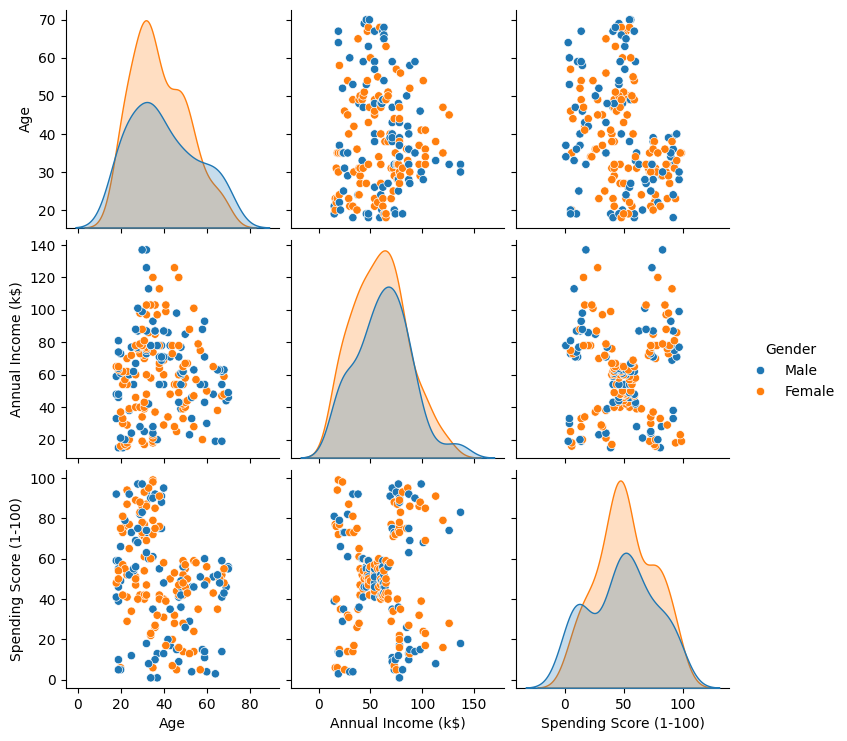

In [11]:
sns.pairplot(
    df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)',
        'Gender']],
    hue='Gender'
)

plt.show()

### Observation

- Pair plots show relationships between numerical features.
- No obvious linear relationship exists between income and spending score.
- Clusters are expected to become visible after applying K-Means.

# EDA Summary

### Key Findings

- Dataset is clean with no missing values.
- No duplicate records are present.
- Gender distribution is nearly balanced.
- Customers belong to various age groups.
- Annual income varies considerably.
- Spending behavior differs among customers.
- No severe outliers were detected.
- Numerical features have weak correlations.

### Conclusion

The dataset is suitable for K-Means clustering after selecting the relevant numerical features and applying feature scaling.

# Data Preprocessing

## Objective

Prepare the dataset for K-Means Clustering by:

- Selecting the appropriate features
- Encoding categorical data (if required)
- Scaling the numerical features
- Creating the final dataset for clustering

In [12]:
# Dispay Dataset
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Feature Selection

The dataset contains the following columns:

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

### Selected Features

For customer segmentation, we will use:

- Age
- Annual Income (k$)
- Spending Score (1-100)

### Excluded Features

- CustomerID → Unique identifier, does not contribute to clustering.
- Gender → Categorical feature. For this project, we will not use it because the objective is to segment customers based on purchasing behavior rather than demographics.

In [13]:
# Selecting features for clustering

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [14]:
print("Selected Dataset Shape:", X.shape)

Selected Dataset Shape: (200, 3)


## Feature Scaling

The selected features have different ranges.

For example:

- Age ranges approximately from 18 to 70
- Annual Income ranges from 15 to 137
- Spending Score ranges from 1 to 99

K-Means uses Euclidean Distance.

Without scaling, features with larger values dominate the clustering process.

Therefore, StandardScaler is used.

# Standardize Features

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [16]:
# verify the scaling by checking the mean and standard deviation of the scaled features
X_scaled.describe().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


In [17]:
print("Before Scaling")
display(X.head())

print("\nAfter Scaling")
display(X_scaled.head())

Before Scaling


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40



After Scaling


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## Preprocessing Summary

Completed preprocessing steps:

✔ Selected relevant numerical features

✔ Removed unnecessary columns

✔ Standardized all selected features

The dataset is now ready for:

- Elbow Method
- K-Means Clustering

# Finding the Optimal Number of Clusters (Elbow Method)

## Objective

Before training the K-Means model, we need to determine the optimal number of clusters (K).

The Elbow Method helps identify the best value of K by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K.

The optimal K is chosen where adding more clusters no longer significantly reduces WCSS, creating an "elbow" in the graph.

In [18]:
# Import KMeans from sklearn.cluster
from sklearn.cluster import KMeans

# Calculate WCSS (Within-Cluster Sum of Squares) for different number of clusters

In [21]:
# Store WCSS values
wcss = []

# Calculate WCSS for K values from 1 to 10
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Display WCSS values
wcss

[599.9999999999999,
 389.3861889564372,
 295.2122461555488,
 205.22514747675913,
 168.24758017556834,
 133.86842085478855,
 117.01155455889813,
 103.87329152383714,
 93.09289110041726,
 82.38515364526599]

# Plot Elbow Curve

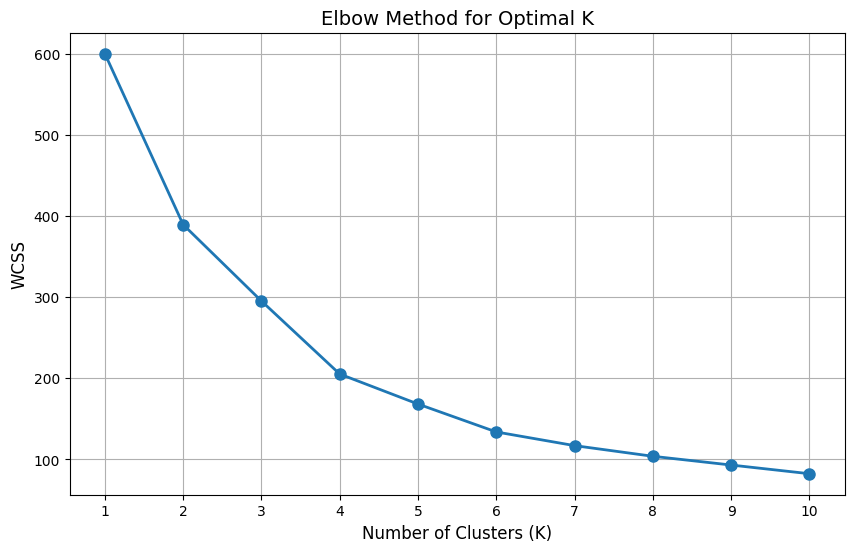

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title("Elbow Method for Optimal K", fontsize=14)

plt.xlabel("Number of Clusters (K)", fontsize=12)

plt.ylabel("WCSS", fontsize=12)

plt.xticks(range(1,11))

plt.grid(True)

plt.show()

## Observation

- As the number of clusters increases, the WCSS decreases.
- Initially, the reduction in WCSS is significant.
- After a certain point, the decrease becomes gradual.
- This point forms the "elbow" of the graph.

The elbow indicates the optimal number of clusters for the dataset.

# Display WCSS Table

In [23]:
wcss_df = pd.DataFrame({
    "Number of Clusters (K)": range(1,11),
    "WCSS": wcss
})

wcss_df

,Number of Clusters (K),WCSS
0,1,600.000000
1,2,389.386189
2,3,295.212246
3,4,205.225147
4,5,168.247580
5,6,133.868421
6,7,117.011555
7,8,103.873292
8,9,93.092891
9,10,82.385154


# Optimal Number of Clusters

From the Elbow Method graph, the elbow occurs at:

## K = 5

This means dividing the customers into **5 clusters** provides a good balance between simplicity and minimizing WCSS.

Therefore, we will use:

**Number of Clusters = 5**

In [24]:
# Optimal number of clusters
optimal_k = 5

print("Optimal Number of Clusters:", optimal_k)

Optimal Number of Clusters: 5


# K-Means Model Training

## Objective

In this phase, we will:

- Train the K-Means model using the optimal number of clusters.
- Assign every customer to a cluster.
- Store the cluster labels.
- Find the cluster centroids.
- Analyze the characteristics of each customer segment.

# Training the K-Means Mode

In [25]:
# Train the K-Means model

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


# Predict Cluster Labels

In [26]:
# Predict customer clusters

clusters = kmeans.predict(X_scaled)

clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

# Add Cluster Labels to Dataset

In [27]:
# Add cluster labels to the original dataset

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


# Number of Customers per Cluster

In [28]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

# Display Cluster Count Table

In [29]:
cluster_summary = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Number of Customers": cluster_counts.values
})

cluster_summary

,Cluster,Number of Customers
0,0,20
1,1,54
2,2,40
3,3,39
4,4,47


# Cluster Distribution Plot

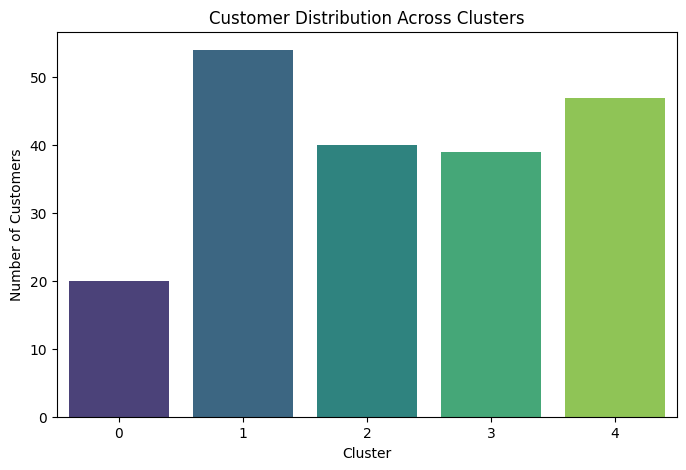

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=df,
    palette="viridis"
)

plt.title("Customer Distribution Across Clusters")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

# Cluster Centroids

In [31]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

centroids

,Age,Annual Income (k$),Spending Score (1-100)
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Cluster Centroids

The centroid represents the average customer profile within each cluster.

Each centroid contains:

- Average Age
- Average Annual Income
- Average Spending Score

These values help us understand the characteristics of each customer group.

# Cluster-wise Statistics

In [32]:
cluster_statistics = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

cluster_statistics

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [ ]:
# Sample Customers from Each Cluster
df.groupby("Cluster").head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
5,6,Female,22,17,76,1
6,7,Female,35,18,6,0
8,9,Male,64,19,3,0
10,11,Male,67,19,14,0
12,13,Female,58,20,15,0


# Observations

- Every customer has been successfully assigned to a cluster.
- Customers within the same cluster have similar purchasing characteristics.
- Different clusters represent different customer segments.
- The centroid values summarize the average profile of each customer segment.

In [34]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save K-Means model
joblib.dump(kmeans, "../models/kmeans_model.pkl")

# Save StandardScaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [35]:
import os

print("Saved Files:")

for file in os.listdir("../models"):
    print(file)

Saved Files:
.gitkeep
kmeans_model.pkl
scaler.pkl


# Cluster Visualization & Business Insights

## Objective

After training the K-Means model, visualize the customer clusters and analyze their characteristics.

These insights help businesses understand different customer segments and create targeted marketing strategies.

# 2D Cluster Visualization

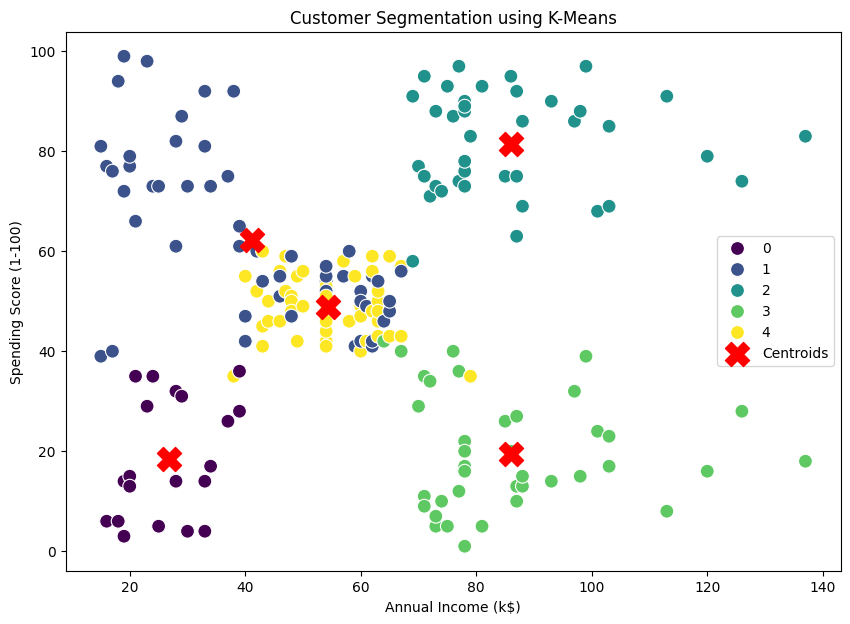

In [36]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

# Plot cluster centroids
plt.scatter(
    centroids['Annual Income (k$)'],
    centroids['Spending Score (1-100)'],
    color='red',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

## Observation

- Customers are grouped into five distinct clusters.
- Each color represents one customer segment.
- The red "X" markers represent the cluster centroids.
- Customers within the same cluster exhibit similar purchasing behavior.

# Age Distribution by Cluster

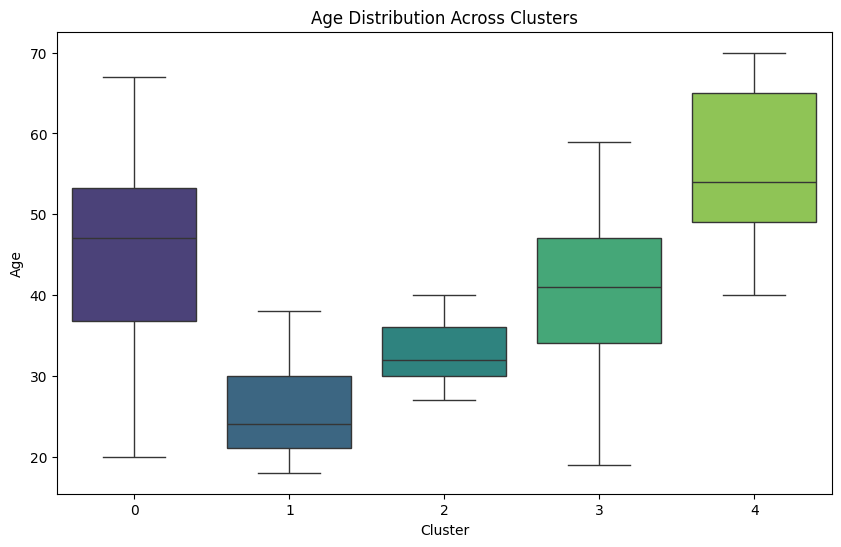

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Age',
    data=df,
    palette='viridis'
)

plt.title("Age Distribution Across Clusters")

plt.show()

# Annual Income by Cluster

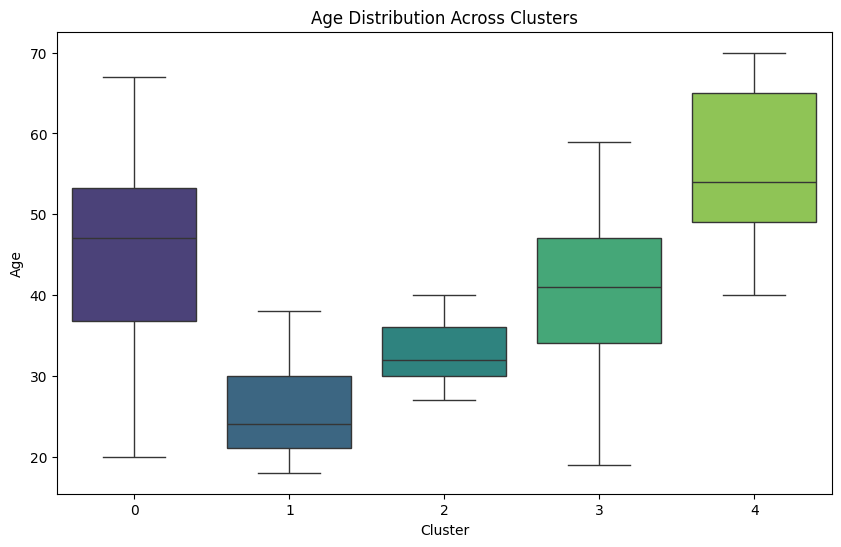

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Age',
    data=df,
    palette='viridis'
)

plt.title("Age Distribution Across Clusters")

plt.show()

# Annual Income by Cluster

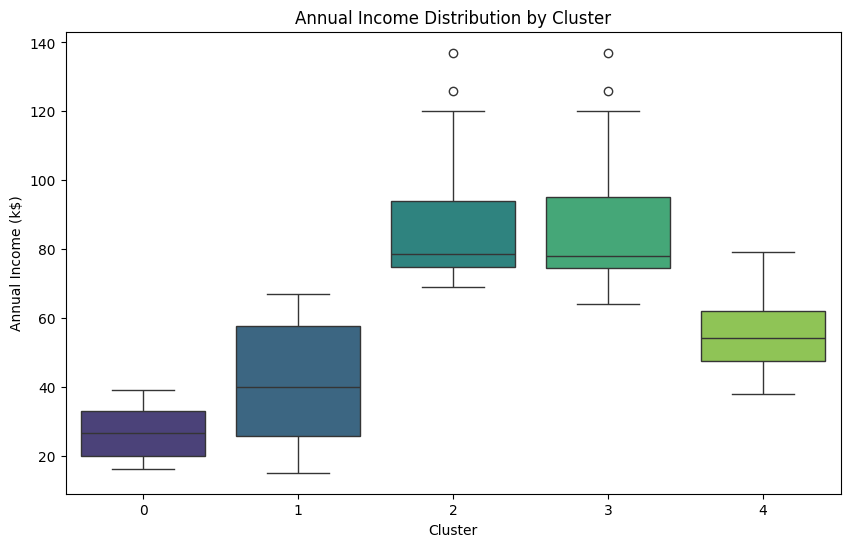

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Annual Income (k$)',
    data=df,
    palette='viridis'
)

plt.title("Annual Income Distribution by Cluster")

plt.show()

# Spending Score by Cluster

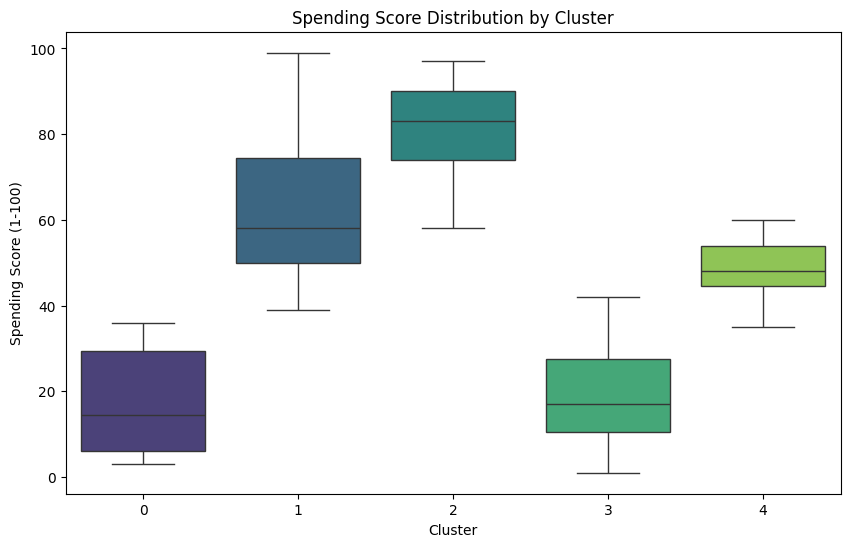

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Spending Score (1-100)',
    data=df,
    palette='viridis'
)

plt.title("Spending Score Distribution by Cluster")

plt.show()

# Average Values per Cluster

In [41]:
cluster_profile = df.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
}).round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


# Business Interpretation of Clusters

## Cluster 0
- Medium income
- Medium spending
- Regular customers

### Business Strategy
Offer loyalty programs and seasonal discounts.

---

## Cluster 1
- High income
- High spending

### Business Strategy
Premium memberships, exclusive products, VIP rewards.

---

## Cluster 2
- Low income
- High spending

### Business Strategy
Provide affordable bundles and promotional offers.

---

## Cluster 3
- High income
- Low spending

### Business Strategy
Increase engagement through personalized marketing and product recommendations.

---

## Cluster 4
- Low income
- Low spending

### Business Strategy
Target with discounts, coupons, and introductory offers.

# Cluster Summary Table

In [42]:
cluster_summary = df.groupby("Cluster").agg({
    "CustomerID":"count",
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
})

cluster_summary.rename(columns={
    "CustomerID":"Total Customers"
}, inplace=True)

cluster_summary.round(2)

,Total Customers,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,20,46.25,26.75,18.35
1,54,25.19,41.09,62.24
2,40,32.88,86.10,81.53
3,39,39.87,86.10,19.36
4,47,55.64,54.38,48.85


In [43]:
import os

# Create output directory if it doesn't exist
os.makedirs("../output", exist_ok=True)

# Save clustered dataset
df.to_csv("../output/customer_segments.csv", index=False)

print("Clustered dataset exported successfully!")

Clustered dataset exported successfully!


# Project Conclusion

## Summary

This project successfully applied the K-Means Clustering algorithm to segment retail customers based on purchasing behavior.

### Key Steps Completed

- Imported the dataset
- Performed Exploratory Data Analysis (EDA)
- Preprocessed the data
- Standardized numerical features
- Determined the optimal number of clusters using the Elbow Method
- Trained the K-Means model
- Assigned cluster labels
- Visualized customer segments
- Generated business insights
- Saved the trained model
- Exported the clustered dataset

## Business Value

Customer segmentation enables businesses to:

- Identify premium customers
- Design personalized marketing campaigns
- Improve customer retention
- Optimize promotional strategies
- Enhance overall customer satisfaction